In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler


In [2]:
# Load the dataset
#url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls'
df = pd.read_excel('Concrete_Data.xls')

# Display dimensions
print("Dataset dimensions:", df.shape)

# Display summary statistics
print("\nSummary statistics:")
print(df.describe())

Dataset dimensions: (1030, 9)

Summary statistics:
       Cement (component 1)(kg in a m^3 mixture)  \
count                                1030.000000   
mean                                  281.165631   
std                                   104.507142   
min                                   102.000000   
25%                                   192.375000   
50%                                   272.900000   
75%                                   350.000000   
max                                   540.000000   

       Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
count                                        1030.000000       
mean                                           73.895485       
std                                            86.279104       
min                                             0.000000       
25%                                             0.000000       
50%                                            22.000000       
75%                             

In [3]:
# Display info
print("\nDataset info:")
print(df.info())



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascal

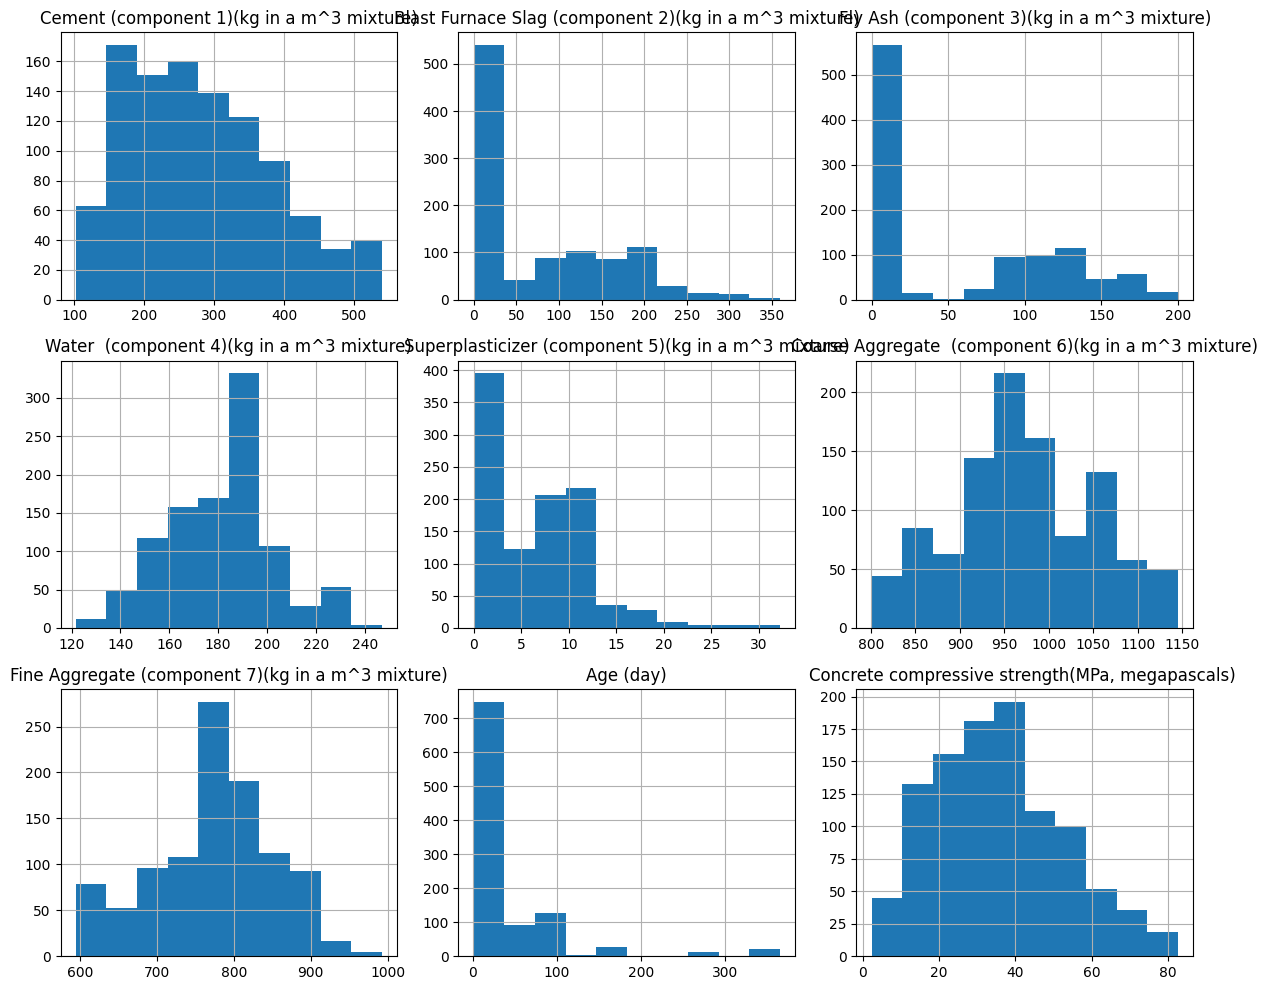

In [4]:
# Visualization: Histograms for all features
df.hist(figsize=(12, 10))
plt.tight_layout()                 #This function automatically adjusts spacing between plots
plt.show()


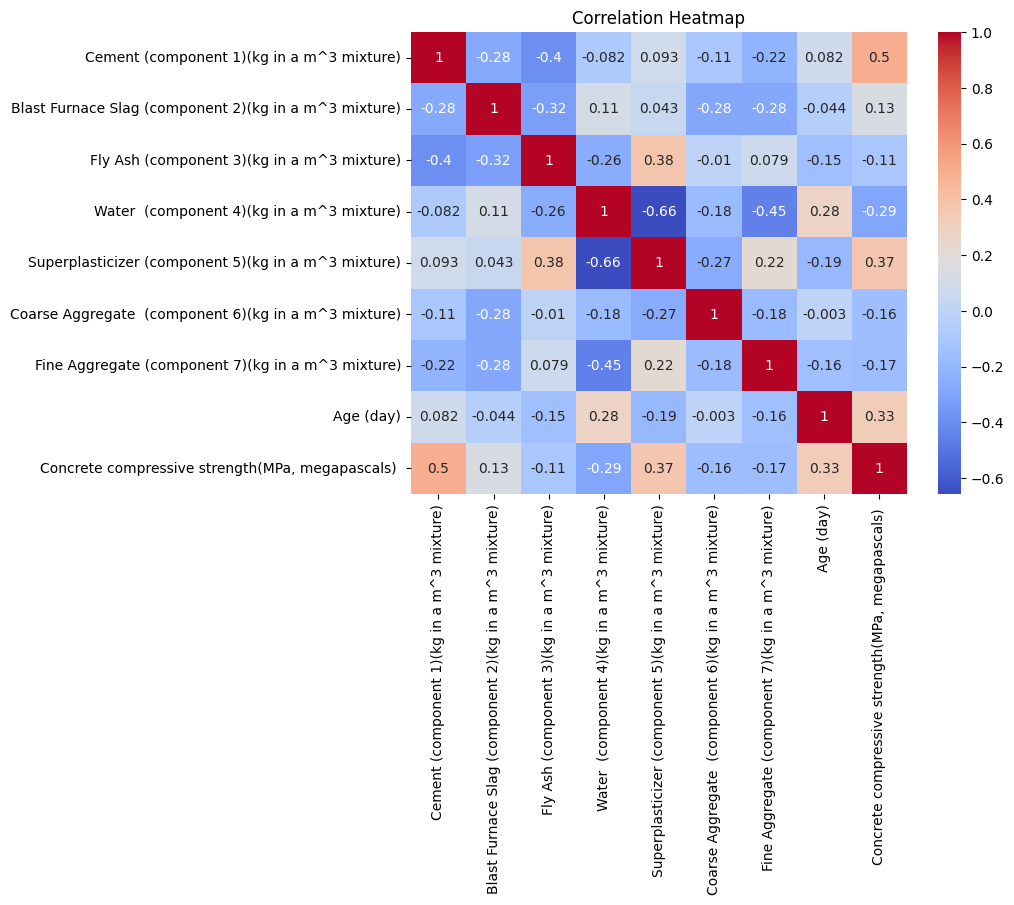

In [5]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [6]:
# Task 2: Data Cleaning & Transformation

# Check for missing values
print("Missing values:")
print(df.isnull().sum())


Missing values:
Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64


In [7]:
# Outlier detection using IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print("\nOutliers per column:")
print(outliers)


Outliers per column:
Cement (component 1)(kg in a m^3 mixture)                 0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)     2
Fly Ash (component 3)(kg in a m^3 mixture)                0
Water  (component 4)(kg in a m^3 mixture)                 9
Superplasticizer (component 5)(kg in a m^3 mixture)      10
Coarse Aggregate  (component 6)(kg in a m^3 mixture)      0
Fine Aggregate (component 7)(kg in a m^3 mixture)         5
Age (day)                                                59
Concrete compressive strength(MPa, megapascals)           4
dtype: int64


In [8]:
# Handling outliers: Cap them at IQR bounds
df_capped = df.copy()
for col in df.columns:
    df_capped[col] = np.where(df_capped[col] < (Q1[col] - 1.5 * IQR[col]), Q1[col] - 1.5 * IQR[col], df_capped[col])
    df_capped[col] = np.where(df_capped[col] > (Q3[col] + 1.5 * IQR[col]), Q3[col] + 1.5 * IQR[col], df_capped[col])



In [9]:

# Feature Scaling using StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_capped), columns=df.columns)

In [10]:
# Task 3: Simple Linear Regression

# Select one independent variable: Cement (first column)
X_simple = df_scaled.iloc[:, 0].values.reshape(-1, 1)  # Cement
y = df_scaled.iloc[:, -1].values  # Concrete compressive strength




In [11]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)


In [12]:
# Build the model
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Predict
y_pred_simple = model_simple.predict(X_test)

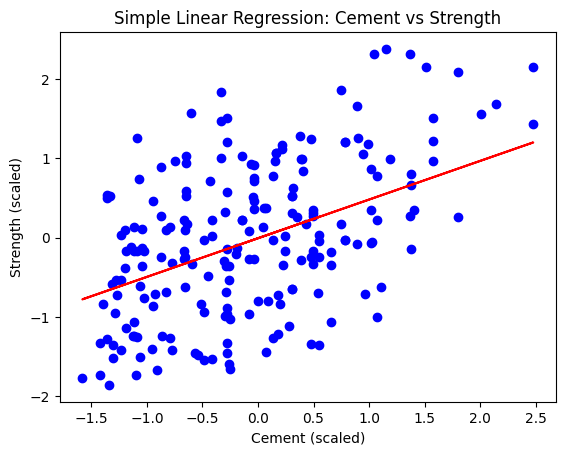

In [13]:
# Plot the regression line
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred_simple, color='red')
plt.title('Simple Linear Regression: Cement vs Strength')
plt.xlabel('Cement (scaled)')
plt.ylabel('Strength (scaled)')
plt.show()


In [14]:

# Evaluate
r2_simple = r2_score(y_test, y_pred_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
print(f"Simple Linear Regression - R²: {r2_simple:.4f}, MAE: {mae_simple:.4f}, MSE: {mse_simple:.4f}, RMSE: {rmse_simple:.4f}")


Simple Linear Regression - R²: 0.2518, MAE: 0.6927, MSE: 0.6927, RMSE: 0.8323


In [15]:
# Task 4: Multiple Linear Regression

# Use all features except the target
X_multi = df_scaled.iloc[:, :-1]

# Split into training and testing sets
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Build the model
model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)

# Predict
y_pred_multi = model_multi.predict(X_test_multi)


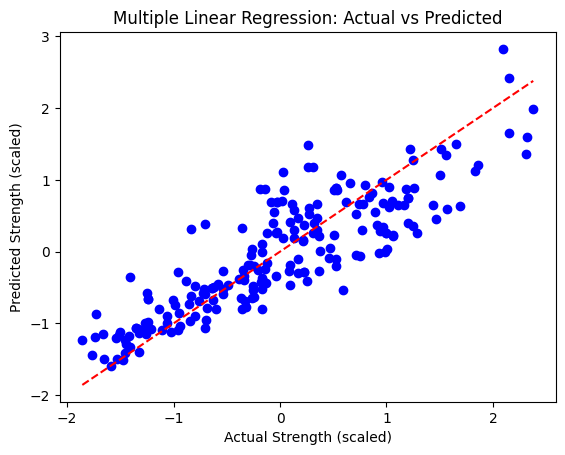

In [16]:
# Plot actual vs predicted (since multiple features, can't plot regression line directly)
plt.scatter(y_test_multi, y_pred_multi, color='blue')
plt.plot([y_test_multi.min(), y_test_multi.max()], [y_test_multi.min(), y_test_multi.max()], color='red', linestyle='--')
plt.title('Multiple Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Strength (scaled)')
plt.ylabel('Predicted Strength (scaled)')
plt.show()

In [17]:
# Evaluate
r2_multi = r2_score(y_test_multi, y_pred_multi)
mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
print(f"Multiple Linear Regression - R²: {r2_multi:.4f}, MAE: {mae_multi:.4f}, MSE: {mse_multi:.4f}, RMSE: {rmse_multi:.4f}")

Multiple Linear Regression - R²: 0.7459, MAE: 0.3825, MSE: 0.2352, RMSE: 0.4850
